<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 15 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Charts for Numerical Data" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(155)
INK="#1a2138"; CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · THE BIN TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Same data, different shape</div>
<div style="color:#4a5578;margin-top:6px">Generate rng.normal(0,1,2000) and plot it as a histogram with 3 bins and again with 80 bins. Describe how the apparent shape changes, and compute the Freedman-Diaconis bin count.</div>
</div>

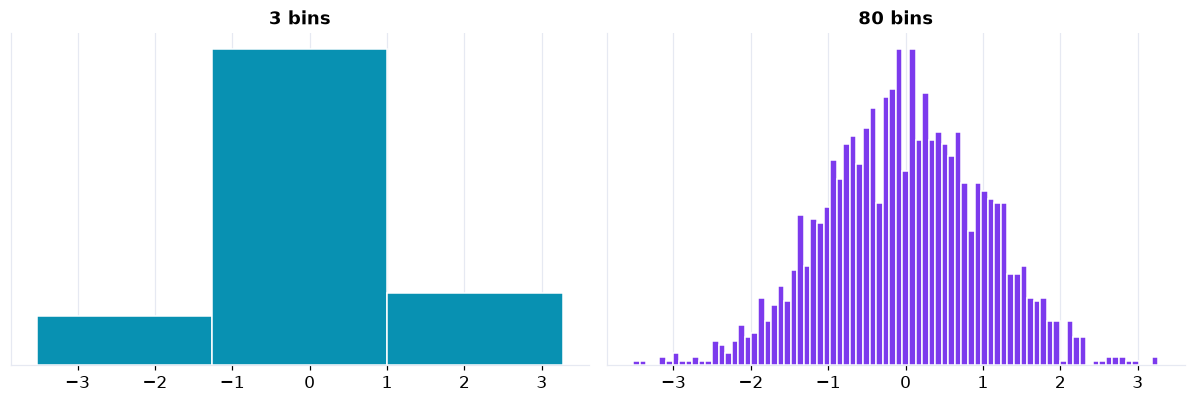

Freedman-Diaconis suggests about 30 bins


In [2]:
data = rng.normal(0, 1, 2000)
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,3.8))
a1.hist(data, bins=3, color=CYAN, edgecolor="white"); a1.set_title("3 bins"); a1.set_yticks([])
a2.hist(data, bins=80, color=PURPLE, edgecolor="white"); a2.set_title("80 bins"); a2.set_yticks([])
plt.tight_layout(); plt.show()
iqr=np.subtract(*np.percentile(data,[75,25])); w=2*iqr/len(data)**(1/3)
fd=int((data.max()-data.min())/w)
print(f"Freedman-Diaconis suggests about {fd} bins")

**Answer:** With 3 bins the bell looks like a crude block and detail is lost; with 80 bins random noise makes it look jagged and multi-peaked. The true shape (a single smooth bell) is only clear at a sensible bin count, here Freedman-Diaconis suggests roughly 30. The lesson: a histogram's shape is partly a choice, so try several binnings.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · WHAT THE BOX HIDES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Box vs the real shape</div>
<div style="color:#4a5578;margin-top:6px">Build one dataset that is clearly bimodal. Show it as a box plot and as a histogram side by side. What does the box plot fail to reveal?</div>
</div>

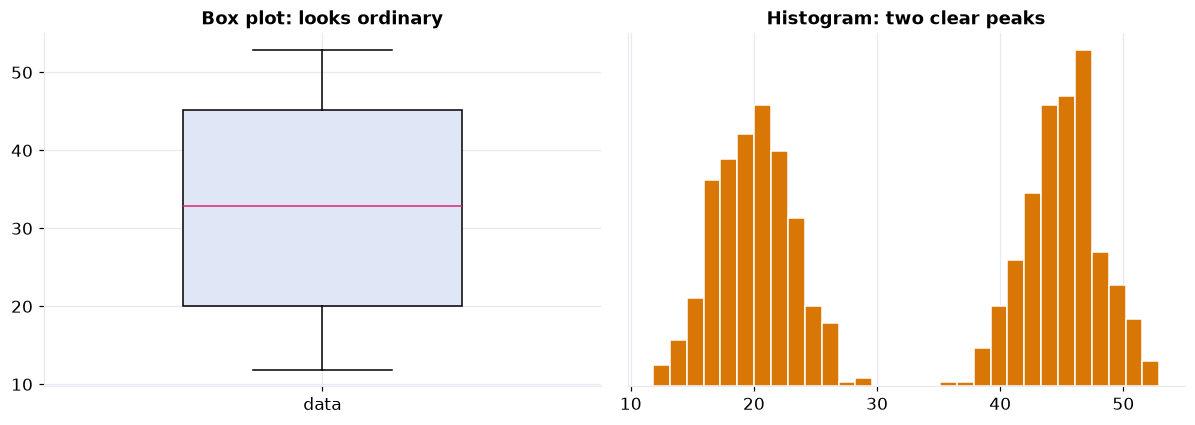

In [3]:
bimodal = np.concatenate([rng.normal(20,3,400), rng.normal(45,3,400)])
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
bp=a1.boxplot(bimodal, patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#dfe7f7"); bp["medians"][0].set_color(PINK)
a1.set_xticks([1]); a1.set_xticklabels(["data"]); a1.set_title("Box plot: looks ordinary")
a2.hist(bimodal, bins=30, color=AMBER, edgecolor="white"); a2.set_title("Histogram: two clear peaks"); a2.set_yticks([])
plt.tight_layout(); plt.show()

**Answer:** The box plot shows a median, a box, and whiskers that look unremarkable, it gives no hint that the data has **two separate peaks**. Box plots cannot show modality, so two very different distributions can share one box. When shape matters, add a histogram, violin, or strip plot.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · PICK THE CHART</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Match question to chart</div>
<div style="color:#4a5578;margin-top:6px">Name the best chart for each: (a) the distribution of one exam's scores; (b) comparing salaries across five departments; (c) a company's monthly revenue over three years; (d) the relationship between advertising spend and sales.</div>
</div>

In [4]:
answers = {
  "(a) one variable's distribution": "Histogram (or box/violin)",
  "(b) compare across 5 groups":     "Box plots side by side",
  "(c) value over time":             "Line chart",
  "(d) relationship between two":    "Scatter plot",
}
for q,a in answers.items(): print(f"{q:34} -> {a}")

(a) one variable's distribution    -> Histogram (or box/violin)
(b) compare across 5 groups        -> Box plots side by side
(c) value over time                -> Line chart
(d) relationship between two       -> Scatter plot


**Answer:** (a) **Histogram** to see one variable's shape; (b) **side-by-side box plots** to compare groups compactly; (c) **line chart** for a value over ordered time; (d) **scatter plot** for the relationship between two numeric variables. The heuristic: one variable to histogram, groups to box plots, time to line, two variables to scatter.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · AXIS HONESTY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Truncated vs honest line</div>
<div style="color:#4a5578;margin-top:6px">A revenue series barely changes over a year. Show it on a truncated y-axis and on a full one. Does a line chart have to start at zero? Explain.</div>
</div>

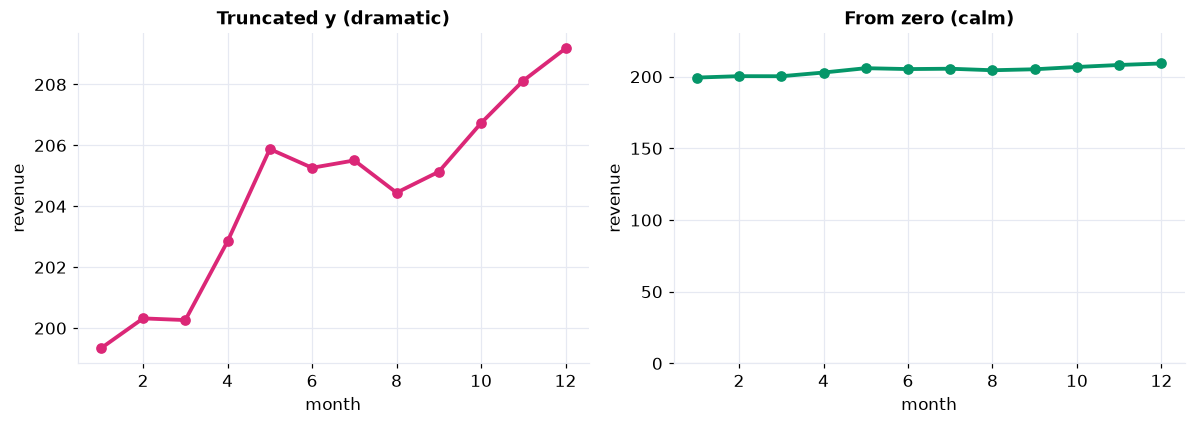

In [5]:
months=np.arange(1,13); rev=200+np.cumsum(rng.normal(0.5,1.2,12))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
a1.plot(months,rev,color=PINK,lw=2.5,marker="o"); a1.set_title("Truncated y (dramatic)")
a2.plot(months,rev,color=GREEN,lw=2.5,marker="o"); a2.set_ylim(0, rev.max()*1.1); a2.set_title("From zero (calm)")
for ax in (a1,a2): ax.set_xlabel("month"); ax.set_ylabel("revenue")
plt.tight_layout(); plt.show()

**Answer:** A line chart does **not** have to start at zero, because position (not bar length) encodes the value, so zooming in to show real variation is legitimate (Tufte: show the data, not the zero point). The catch is honesty: the same freedom lets you exaggerate a trivial wiggle into a cliff. Choose a scale that reflects the real variation and label the axis clearly.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · ALWAYS PLOT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Same stats, different data</div>
<div style="color:#4a5578;margin-top:6px">Two of Anscombe's datasets share the same mean, correlation, and regression line. Confirm the stats match, then plot both. What is the moral?</div>
</div>

Dataset I: mean y=7.50, r=0.82, line y=0.50x+3.00
Dataset II: mean y=7.50, r=0.82, line y=0.50x+3.00


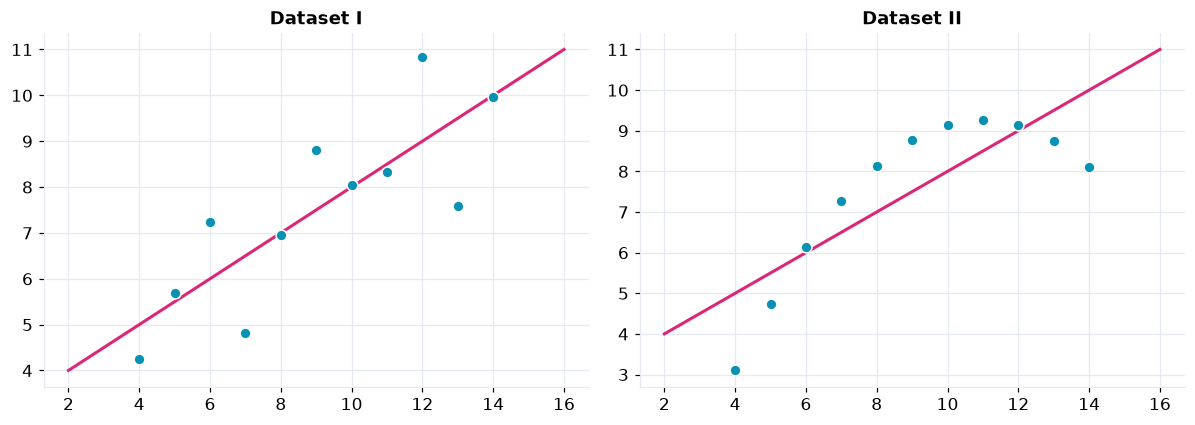

In [6]:
x = np.array([10,8,13,9,11,14,6,4,12,7,5], float)
yI  = np.array([8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68])
yII = np.array([9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74])
for name,y in [("I",yI),("II",yII)]:
    m,b=np.polyfit(x,y,1); r=np.corrcoef(x,y)[0,1]
    print(f"Dataset {name}: mean y={y.mean():.2f}, r={r:.2f}, line y={m:.2f}x+{b:.2f}")
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
for ax,(name,y) in zip((a1,a2), [("I",yI),("II",yII)]):
    ax.scatter(x,y,color=CYAN,s=50,edgecolor="white",zorder=5)
    ax.plot([2,16],[3+0.5*2,3+0.5*16],color=PINK,lw=2); ax.set_title(f"Dataset {name}")
plt.tight_layout(); plt.show()

**Answer:** Both datasets give essentially the same mean, correlation (r ≈ 0.82), and regression line y = 3 + 0.5x, yet Dataset I is genuinely linear while Dataset II is a clear **curve** that a straight line misfits. The moral, straight from Anscombe: summary statistics can be identical for very different data, so **always plot your data** before trusting a number.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You exposed the histogram bin trap, saw what a box plot hides, matched questions to chart types, weighed axis honesty on line charts, and proved with Anscombe that the picture beats the summary. You now wield the core numeric-EDA toolkit with a critical eye.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>